In [8]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Cargar variables de entorno
load_dotenv()

url = "https://api.thedogapi.com/v1/breeds"
api_key = os.getenv('API_KEY')

# Verificar si la clave existe
if not api_key:
    print("Error: No se encontró la API_KEY en el archivo .env. Obtén una clave gratuita en https://thedogapi.com/")
    exit(1)

# Agregar la clave en los encabezados
headers = {'x-api-key': api_key}

try:
    respuesta = requests.get(url, headers=headers)
    respuesta.raise_for_status()  # Lanza error si la respuesta no es 200
    data = respuesta.json()
    
    if not data:
        print("La API no devolvió datos. Verifica tu clave o la URL.")
    else:
        df = pd.DataFrame(data)
        print(df.head())
except requests.exceptions.RequestException as e:
    print(f"Error en la solicitud: {e}")
except ValueError as e:
    print(f"Error al procesar los datos: {e}")

  id              name species_id life_span  \
0  1     Affenpinscher          2     12-15   
1  2      Afghan Hound          2     12-15   
2  4  Airedale Terrier          2     11-14   
3  5            Akbash          2     10-12   
4  6             Akita          2     10-13   

                                         temperament              origin  \
0       Confident, alert, playful, loyal, courageous             Germany   
1    Independent, dignified, aloof, loyal, confident         Afghanistan   
2  Confident, intelligent, courageous, alert, ene...  Yorkshire, England   
3  Independent, protective, calm, alert, loyal, i...      Western Turkey   
4  Courageous, loyal, dignified, independent, pro...               Japan   

  country_codes country_code  \
0            DE           DE   
1            AF           AF   
2            GB           GB   
3            TR           TR   
4            JP           JP   

                                         description bred_for perfe

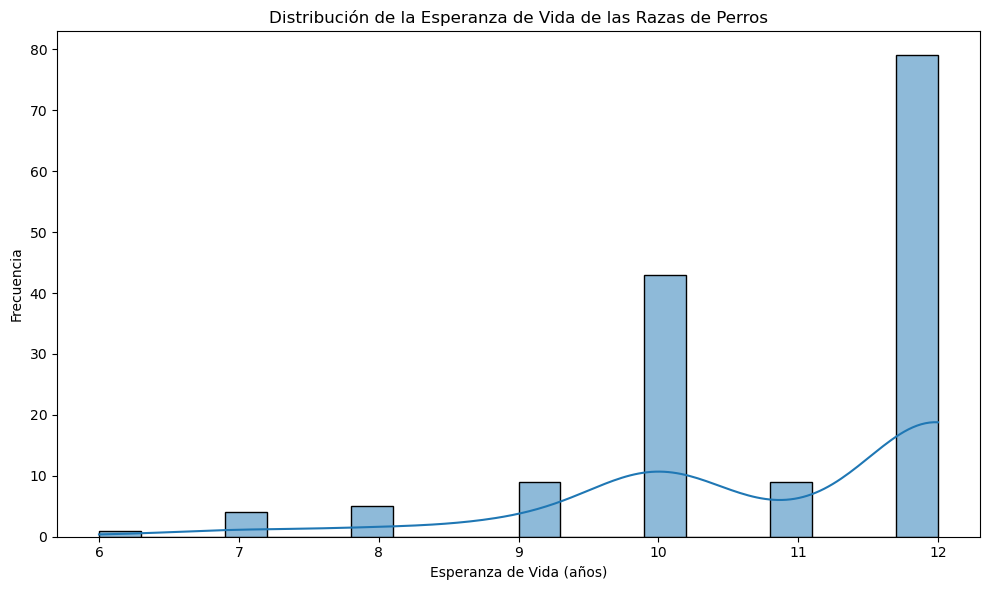

In [ ]:
# Extraer el primer número de 'life_span' de forma segura
df['life_span'] = (
    df['life_span']
    .astype(str)                           # asegura tipo string
    .str.extract(r'(\d+)')                 # extrae primer número
    .astype(float)                         # convierte a numérico
)

# Eliminar filas con valores nulos en columnas clave
df = df.dropna(subset=['life_span', 'temperament'])

# Mantener solo columnas necesarias
columnas_de_interes = ['life_span', 'temperament']
df = df[columnas_de_interes]

# --- Visualización ---

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='life_span',
    kde=True,
    bins=20
)

plt.title('Distribución de la Esperanza de Vida de las Razas de Perros')
plt.xlabel('Esperanza de Vida (años)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

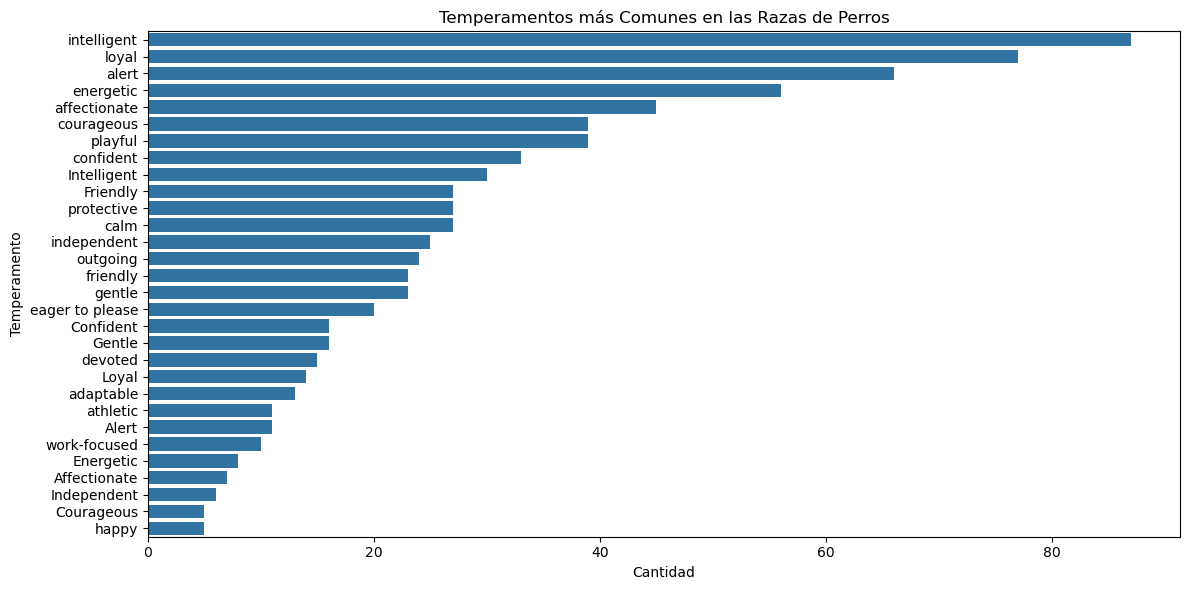

In [12]:
# Crear un gráfico de barras con los temperamentos más frecuentes

# Dividir los temperamentos en palabras individuales (vectorizado)
temperamentos = (
    df['temperament']
    .dropna()
    .str.split(', ')
    .explode()
)

# Contar los temperamentos más frecuentes
conteo_temperamentos = (
    temperamentos
    .value_counts()
    .head(30)
    .reset_index()
)

conteo_temperamentos.columns = ['Temperamento', 'Conteo']

# Graficar
plt.figure(figsize=(12, 6))

sns.barplot(
    data=conteo_temperamentos,
    x='Conteo',
    y='Temperamento'
)

plt.title('Temperamentos más Comunes en las Razas de Perros')
plt.xlabel('Cantidad')
plt.ylabel('Temperamento')

plt.tight_layout()
plt.show()